# LAB 1
En este lab repasaremos los conceptos vistos en la clase 2 Fundamentos de Riesgo y Rendimientos

## Bibliotecas a importar

* yfinance: la usaremos para descargar información
* numpy: la usaremos para realizar diversas operaciones matemáticas
* pandas: la usaremos para realizar cálculos con vectores
* analisis_portafolios: nuestra biblioteca del curso que tendrá funciones para los procedimientos vistos en clase

In [36]:
import yfinance as yf
import numpy as np
import pandas as pd
import analisis_portafolios as ap

## Descargamos la información a analizar

In [37]:
ticker = "AAPL" # ticker de la acción a analizar
fecha_inicio = "2025-01-01" # fecha de inicio para descargar
fecha_fin = "2025-12-31" # fecha final para descargar

In [38]:
datos = yf.download(ticker, start=fecha_inicio, end=fecha_fin)

[*********************100%***********************]  1 of 1 completed


In [39]:
# visualizamos informacion descargada
datos.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.093124,247.305299,240.077751,247.136511,55740700
2025-01-03,241.606659,242.420743,240.147249,241.606659,40244100
2025-01-06,243.234818,245.548032,241.447783,242.549786,45045600
2025-01-07,240.464935,243.780868,239.611131,241.229377,40856000
2025-01-08,240.951401,241.954134,238.320499,240.177022,37628900


El resultado es una tabla que tiene 5 columnas y cada fila corresponde a un día de operación:

* Close: Precio de cierre
* High: Precio máximo del día
* Low: Precio mínimo del día
* Open: Precio de apertura
* Volume: Número de acciones que se intercambiaron en el día (compra o venta)

In [40]:
# extraemos la columna que nos interesa analizar
precio_cierre = datos[("Close", "AAPL")]
precio_cierre.head()

Date
2025-01-02    242.093124
2025-01-03    241.606659
2025-01-06    243.234818
2025-01-07    240.464935
2025-01-08    240.951401
Name: (Close, AAPL), dtype: float64

## Descargar múltiples datos
También es posible descargar información de diferentes empresas en un sólo llamado

In [41]:
datos_multiples = yf.download(["AAPL", "TSLA"], start=fecha_inicio, end=fecha_fin)

[*********************100%***********************]  2 of 2 completed


In [42]:
datos_multiples.head()

Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2025-01-02  242.093124  379.279999  247.305299  392.730011  240.077751   
2025-01-03  241.606659  410.440002  242.420743  411.880005  240.147249   
2025-01-06  243.234818  411.049988  245.548032  426.429993  241.447783   
2025-01-07  240.464935  394.359985  243.780868  414.329987  239.611131   
2025-01-08  240.951401  394.940002  241.954134  402.500000  238.320499   

Price                         Open                Volume             
Ticker            TSLA        AAPL        TSLA      AAPL       TSLA  
Date                                                                 
2025-01-02  373.040009  247.136511  390.100006  55740700  109710700  
2025-01-03  379.450012  241.606659  381.480011  40244100   95423300  
2025-01-06  401.700012  242.549786  423.200012  45045600   85516500  
2025-01-07  390.000000  241.229377  405.829987  40856000   75699500  
2025-01-08  387.399994  240.177022  392.950012  37628900   73038800

## Riesgo y Rendimiento

Para calcular el riesgo y el rendimiento usaremos los precios de cierre como base.

<Axes: xlabel='Date'>

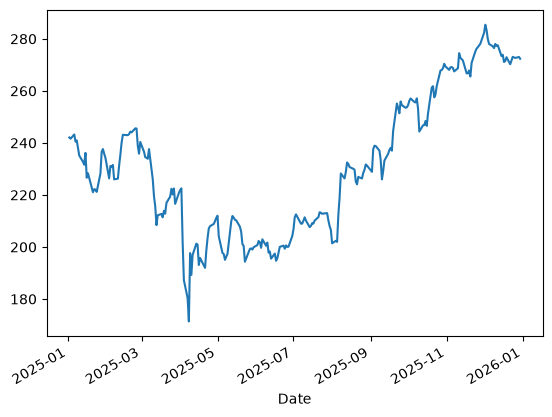

In [43]:
# visualizamos el precio de cierre
precio_cierre.plot()

### Rendimientos porcentuales

Calcular los rendimientos porcentuales es muy sencillo si ya tenemos los precios de cierre. Sólo tenemos utilizar la función "pct_change". La cual realiza la siguiente operación:

$$ R_t=\frac{P_t-P_{t-1}}{P_t} $$

A este rendimiento se le conoce como *rendimiento aritmético simple*.

In [44]:
rend_simple = precio_cierre.pct_change().dropna()

In [45]:
rend_simple.head()

Date
2025-01-03   -0.002009
2025-01-06    0.006739
2025-01-07   -0.011388
2025-01-08    0.002023
2025-01-10   -0.024104
Name: (Close, AAPL), dtype: float64

<Axes: xlabel='Date'>

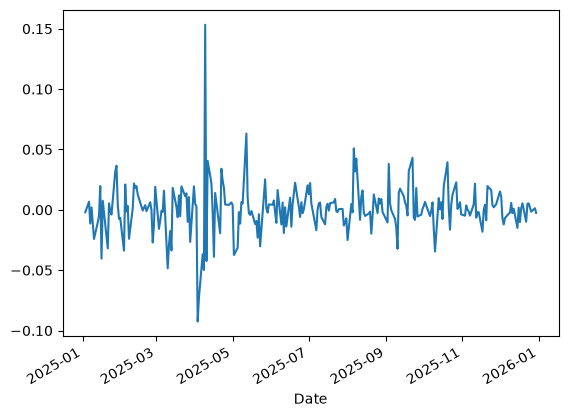

In [46]:
rend_simple.plot()

In [47]:
rend_simple.describe()

count    248.000000
mean       0.000681
std        0.020489
min       -0.092456
25%       -0.006729
50%        0.000791
75%        0.006617
max        0.153288
Name: (Close, AAPL), dtype: float64

### Rendimientos logarítmicos

También podemos calcular los rendimientos logarítmicos:

$$ R_{log} = ln(\frac{P_t}{P_{t-1}})$$

In [48]:
rend_log = np.log(precio_cierre / precio_cierre.shift(1)).dropna()

In [49]:
rend_log.head()

Date
2025-01-03   -0.002011
2025-01-06    0.006716
2025-01-07   -0.011453
2025-01-08    0.002021
2025-01-10   -0.024399
Name: (Close, AAPL), dtype: float64

<Axes: xlabel='Date'>

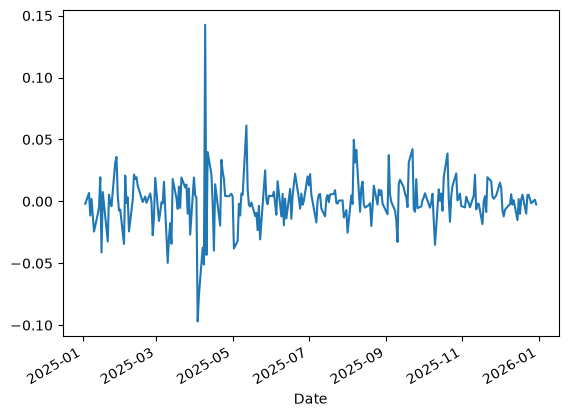

In [50]:
rend_log.plot()

### Rendimiento anualizado
Ahora que ya hemos calculado el rendimiento diario procederemos a calcular el rendimiento anualizado.

**NOTA:** Previamente realizamos dos métodos para obtener los rendimientos diarios (el porcentual y el logaritmico), utilizaremos el porcentual al menos que se especifique lo contrario.

In [51]:
ap.rendimiento_anualizado(rend_simple)

np.float64(0.12707159957495873)

**NOTA**: 
* De manera predeterminada se tendrá que $p=252$ dado que ese es el número aproximado de días de operación de la Bolsa de Valores en 1 año (pues opera de lunes a viernes $ 365 * \frac{5}{7} \approx 261 $ y se consideran $9$ días festivos en Estados Unidos).
* En caso de que la periodicidad de nuestros rendimientos no sea diaria habría que modificar la $p$. Por ejemplo: Si nuestros rendimientos son mensuales usaríamos $p=12$.

### Volatilidad anualizada

In [52]:
ap.volatilidad_anualizada(rend_simple)

np.float64(0.3252560746222333)

## Medidas de Riesgo Ajustado

### Return of Risk Ratio

Rendimiento adicional esperado por unidad de riesgo asumido

In [53]:
ap.return_risk_ratio(rend_simple)

np.float64(0.39068171047241856)

### Sharpe Ratio

Rendimiento extra sobre la tasa libre de riesgo por unidad de riesgo asumido

In [54]:
# asumimos tasa libre de riesgo igual a 0.07
ap.sharpe_ratio(rend_simple, 0.07)

np.float64(0.17546666773631878)

## Max Drawdown

In [55]:
# Calculamos max drawdown
mdd, fecha = ap.max_drawdown(rend_simple)
print(f"Max Drawdown: {mdd:.2%} el día {fecha.strftime('%Y-%m-%d')}")

Max Drawdown: -30.22% el día 2025-04-08


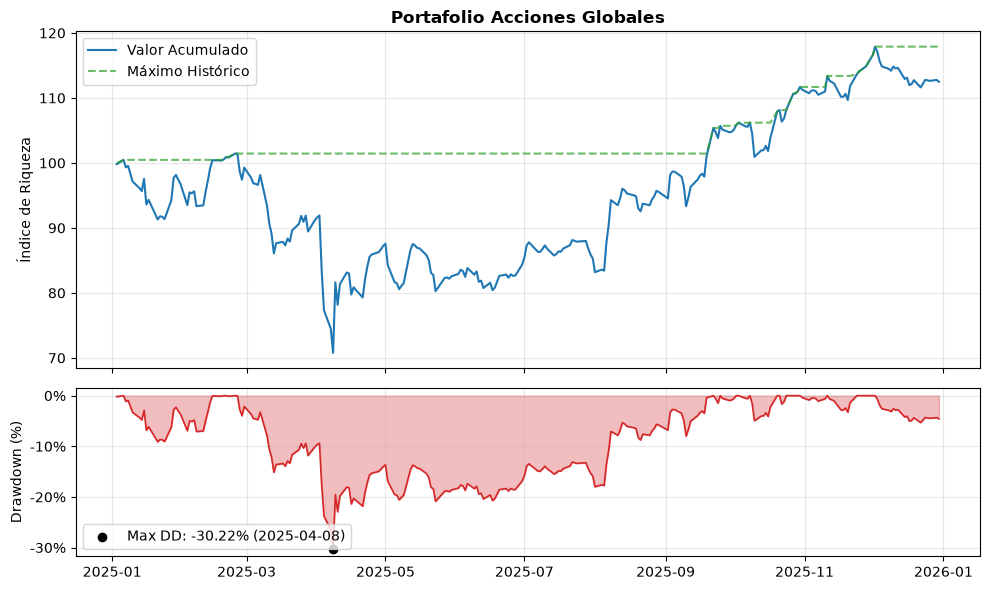

In [56]:
# Visualizamos
fig, ax = ap.plot_drawdown(rend_simple, titulo="Portafolio Acciones Globales")

## Utilizar funciones con mis propios datos

Si queremos utilizar las funciones anteriores con datos que no sean extraídos de yfinance sólo tenemos que escribirlas en el formato adecuado.

Supongamos que queremos analizar el ejemplo de las diapositivas:


In [57]:
fechas = ["2024-06-10", "2024-06-11", "2024-06-12", "2024-06-13", "2024-06-14", "2024-06-15", "2024-06-16", "2024-06-17"]
precios = [41, 40, 37, 36, 39, 42, 37, 39]

In [58]:
serie_precios = pd.Series(
    data = precios,
    index = pd.to_datetime(fechas)
)

In [62]:
rendimientos = serie_precios.pct_change().dropna()

In [63]:
rendimientos

2024-06-11   -0.024390
2024-06-12   -0.075000
2024-06-13   -0.027027
2024-06-14    0.083333
2024-06-15    0.076923
2024-06-16   -0.119048
2024-06-17    0.054054
dtype: float64

In [64]:
# Calculamos max drawdown
mdd, fecha = ap.max_drawdown(rendimientos)
print(f"Max Drawdown: {mdd:.2%} el día {fecha.strftime('%Y-%m-%d')}")

Max Drawdown: -12.20% el día 2024-06-13
